# 🔍 Simple Database Inspector

Direct SQLite analysis of the collateral analysis database.

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

print("📚 Libraries imported successfully")
print(f"📅 Analysis time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

📚 Libraries imported successfully
📅 Analysis time: 2025-09-20 00:48:50


In [2]:
# Connect to database
db_path = Path('collateral_analysis.db')
print(f"📂 Database: {db_path.absolute()}")
print(f"📊 Size: {db_path.stat().st_size / 1024:.1f} KB")
print(f"📅 Modified: {datetime.fromtimestamp(db_path.stat().st_mtime)}")

conn = sqlite3.connect(db_path)
print("✅ Connected to database")

📂 Database: /home/mpo/algorand-showcase/algorand-lending-ecosystem/business-logic-engines/blockchain-collateral-analyzer/collateral-requirements/notebooks/collateral_analysis.db
📊 Size: 96.0 KB
📅 Modified: 2025-09-20 00:37:09.137114
✅ Connected to database


In [3]:
# Show database schema
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]

print(f"📋 Tables: {len(tables)}")
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"  • {table}: {count} records")

📋 Tables: 5
  • collateral_analyses: 41 records
  • sqlite_sequence: 4 records
  • asset_valuations: 44 records
  • market_data_cache: 4 records
  • liquidation_scenarios: 164 records


In [4]:
# Load main data
df = pd.read_sql_query(
    "SELECT * FROM collateral_analyses ORDER BY created_at DESC", 
    conn
)

print(f"📊 Loaded {len(df)} analyses")
print(f"📅 Date range: {df['created_at'].min()} to {df['created_at'].max()}")
print("\nColumns:")
for col in df.columns:
    print(f"  • {col}")

📊 Loaded 41 analyses
📅 Date range: 2025-09-20 00:19:16 to 2025-09-20 00:37:09

Columns:
  • id
  • loan_id
  • analysis_timestamp
  • loan_amount_usd
  • borrower_address
  • analysis_input
  • analysis_output
  • confidence_score
  • risk_level
  • required_collateral_ratio
  • total_collateral_value_usd
  • market_conditions
  • oracle_data_timestamp
  • created_at


In [16]:
# Show sample records
print("📋 Latest 5 records:")
display(df.head(5))

📋 Latest 5 records:


,id,loan_id,analysis_timestamp,loan_amount_usd,borrower_address,analysis_input,analysis_output,confidence_score,risk_level,required_collateral_ratio,total_collateral_value_usd,market_conditions,oracle_data_timestamp,created_at
0,37,NOTEBOOK-TEST-001,2025-09-20 00:37:09,10000.0,None,"{""market_conditions"": ""normal"", ""position_coun...","{""recommendations"": [""Add $9,766 more collater...",0.68,critical,2.145,11683.70,normal,2025-09-20 00:37:09.038354,2025-09-20 00:37:09
1,38,MARKET-BULL,2025-09-20 00:37:09,5000.0,None,"{""market_conditions"": ""bull"", ""position_count""...","{""recommendations"": [""Add $2,645 more collater...",0.68,high,1.931,7010.22,bull,2025-09-20 00:37:09.117656,2025-09-20 00:37:09
2,39,MARKET-NORMAL,2025-09-20 00:37:09,5000.0,None,"{""market_conditions"": ""normal"", ""position_coun...","{""recommendations"": [""Add $3,715 more collater...",0.68,high,2.145,7010.22,normal,2025-09-20 00:37:09.123992,2025-09-20 00:37:09
3,40,MARKET-BEAR,2025-09-20 00:37:09,5000.0,None,"{""market_conditions"": ""bear"", ""position_count""...","{""recommendations"": [""Add $5,325 more collater...",0.68,critical,2.467,7010.22,bear,2025-09-20 00:37:09.128867,2025-09-20 00:37:09
4,41,MARKET-VOLATILE,2025-09-20 00:37:09,5000.0,None,"{""market_conditions"": ""volatile"", ""position_co...","{""recommendations"": [""Add $6,395 more collater...",0.68,critical,2.681,7010.22,volatile,2025-09-20 00:37:09.135164,2025-09-20 00:37:09


⚖️ Risk Distribution:
  critical: 30 (73.2%)
  high: 8 (19.5%)
  medium: 3 (7.3%)


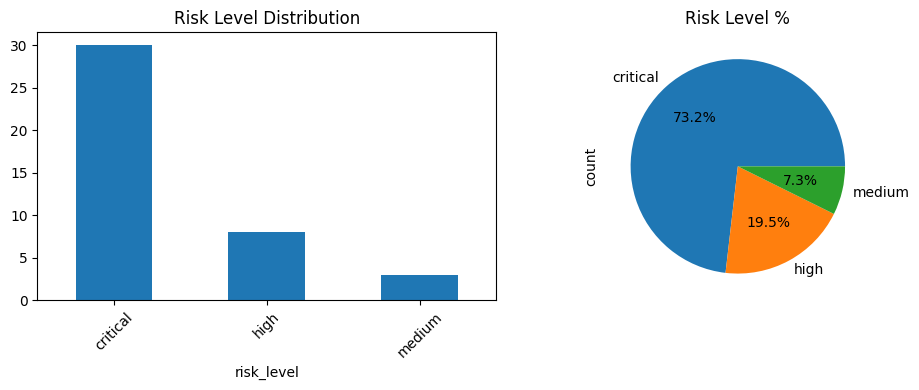

In [6]:
# Risk level analysis
risk_counts = df['risk_level'].value_counts()
print("⚖️ Risk Distribution:")
for risk, count in risk_counts.items():
    pct = count / len(df) * 100
    print(f"  {risk}: {count} ({pct:.1f}%)")

# Plot risk distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
risk_counts.plot(kind='bar')
plt.title('Risk Level Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
risk_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Risk Level %')
plt.tight_layout()
plt.show()

📊 Collateral Ratio Stats:
  Mean: 2.220x
  Median: 2.145x
  Min: 1.663x
  Max: 2.681x
  Std: 0.297x


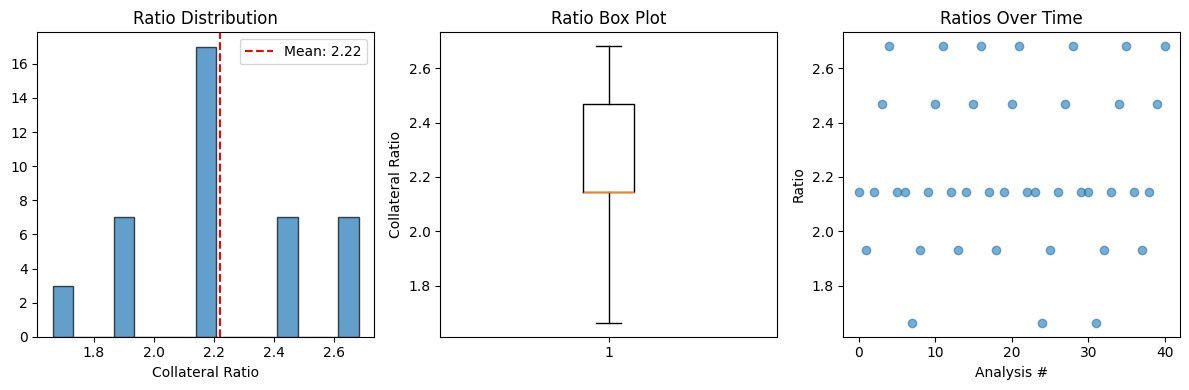

In [7]:
# Collateral ratio analysis
ratios = df['required_collateral_ratio']
print("📊 Collateral Ratio Stats:")
print(f"  Mean: {ratios.mean():.3f}x")
print(f"  Median: {ratios.median():.3f}x")
print(f"  Min: {ratios.min():.3f}x")
print(f"  Max: {ratios.max():.3f}x")
print(f"  Std: {ratios.std():.3f}x")

# Plot distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(ratios, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(ratios.mean(), color='red', linestyle='--', label=f'Mean: {ratios.mean():.2f}')
plt.title('Ratio Distribution')
plt.xlabel('Collateral Ratio')
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot(ratios)
plt.title('Ratio Box Plot')
plt.ylabel('Collateral Ratio')

plt.subplot(1, 3, 3)
plt.scatter(range(len(df)), df['required_collateral_ratio'], alpha=0.6)
plt.title('Ratios Over Time')
plt.xlabel('Analysis #')
plt.ylabel('Ratio')

plt.tight_layout()
plt.show()

💰 Loan Amount Stats:
  Mean: $8,780.49
  Median: $10,000.00
  Min: $5,000.00
  Max: $20,000.00

📊 Loan Ranges:
  <$5K: 19 (46.3%)
  $5K-10K: 16 (39.0%)
  $10K-15K: 3 (7.3%)
  $15K-20K: 3 (7.3%)
  >$20K: 0 (0.0%)


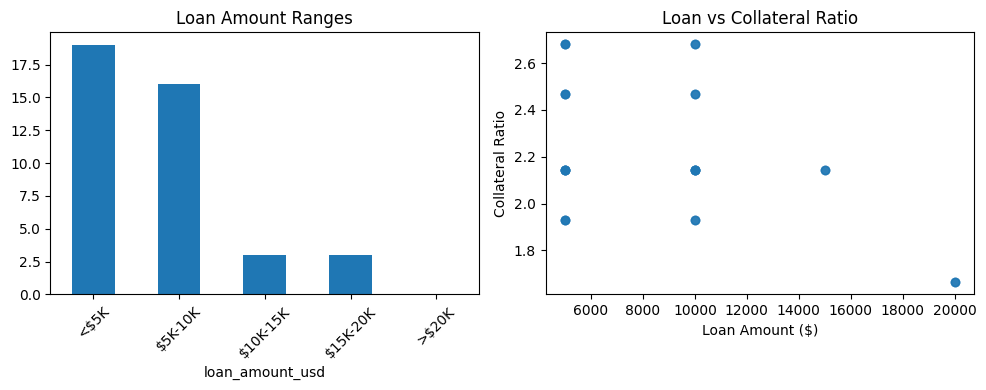

In [8]:
# Loan amount analysis
loans = df['loan_amount_usd']
print("💰 Loan Amount Stats:")
print(f"  Mean: ${loans.mean():,.2f}")
print(f"  Median: ${loans.median():,.2f}")
print(f"  Min: ${loans.min():,.2f}")
print(f"  Max: ${loans.max():,.2f}")

# Loan ranges
ranges = pd.cut(loans, bins=[0, 5000, 10000, 15000, 20000, float('inf')], 
               labels=['<$5K', '$5K-10K', '$10K-15K', '$15K-20K', '>$20K'])
range_counts = ranges.value_counts().sort_index()

print("\n📊 Loan Ranges:")
for r, c in range_counts.items():
    print(f"  {r}: {c} ({c/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
range_counts.plot(kind='bar')
plt.title('Loan Amount Ranges')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.scatter(df['loan_amount_usd'], df['required_collateral_ratio'], alpha=0.6)
plt.title('Loan vs Collateral Ratio')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Collateral Ratio')

plt.tight_layout()
plt.show()

🎯 Confidence Stats:
  Mean: 68.1%
  Median: 68.0%
  Min: 68.0%
  Max: 68.7%


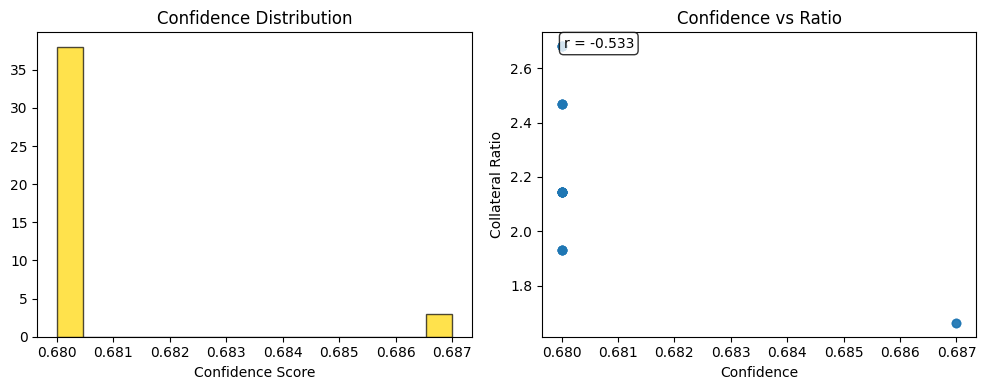

In [9]:
# Confidence score analysis
confidence = df['confidence_score']
print("🎯 Confidence Stats:")
print(f"  Mean: {confidence.mean():.1%}")
print(f"  Median: {confidence.median():.1%}")
print(f"  Min: {confidence.min():.1%}")
print(f"  Max: {confidence.max():.1%}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(confidence, bins=15, edgecolor='black', alpha=0.7, color='gold')
plt.title('Confidence Distribution')
plt.xlabel('Confidence Score')

plt.subplot(1, 2, 2)
plt.scatter(confidence, df['required_collateral_ratio'], alpha=0.6)
plt.title('Confidence vs Ratio')
plt.xlabel('Confidence')
plt.ylabel('Collateral Ratio')

# Add correlation
corr = confidence.corr(df['required_collateral_ratio'])
plt.text(0.05, 0.95, f'r = {corr:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [10]:
# Loan ID patterns
loan_ids = df['loan_id'].tolist()
patterns = {}

for loan_id in loan_ids:
    if 'TEST' in loan_id:
        patterns['TEST'] = patterns.get('TEST', 0) + 1
    elif 'MARKET' in loan_id:
        patterns['MARKET'] = patterns.get('MARKET', 0) + 1
    elif 'MCP' in loan_id:
        patterns['MCP'] = patterns.get('MCP', 0) + 1
    elif 'NOTEBOOK' in loan_id:
        patterns['NOTEBOOK'] = patterns.get('NOTEBOOK', 0) + 1
    else:
        patterns['OTHER'] = patterns.get('OTHER', 0) + 1

print("🔍 Loan ID Patterns:")
for pattern, count in sorted(patterns.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(loan_ids) * 100
    print(f"  {pattern}: {count} ({pct:.1f}%)")

print("\n📋 Sample IDs:")
for i, loan_id in enumerate(df['loan_id'].head(10), 1):
    print(f"  {i:2}. {loan_id}")

🔍 Loan ID Patterns:
  TEST: 21 (51.2%)
  MARKET: 20 (48.8%)

📋 Sample IDs:
   1. NOTEBOOK-TEST-001
   2. MARKET-BULL
   3. MARKET-NORMAL
   4. MARKET-BEAR
   5. MARKET-VOLATILE
   6. MCP-TEST-SMALL-LOAN
   7. MCP-TEST-MEDIUM-LOAN
   8. MCP-TEST-MIXED-PORTFOLIO
   9. MARKET-BULL
  10. MARKET-NORMAL


⏰ Time Analysis:
  Earliest: 2025-09-20 00:19:16
  Latest: 2025-09-20 00:37:09
  Span: 0 days 00:17:53


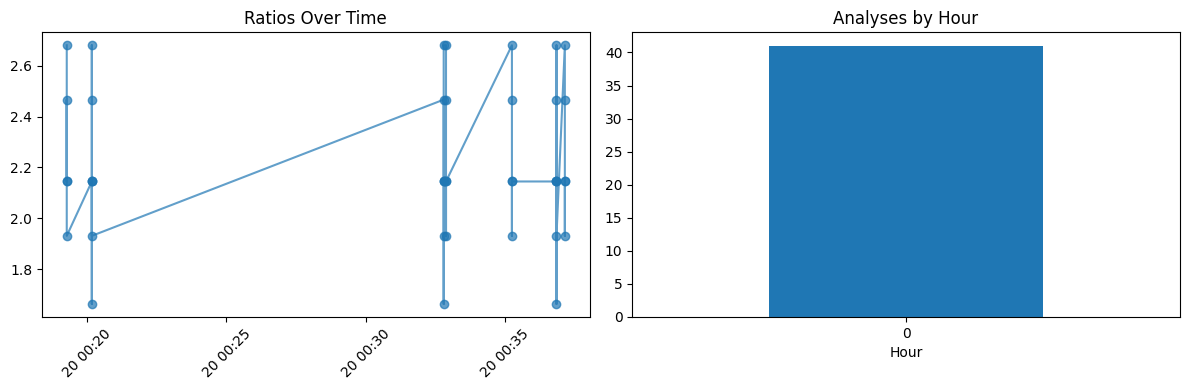

In [11]:
# Time analysis
df['created_at'] = pd.to_datetime(df['created_at'])
df_time = df.sort_values('created_at')

print("⏰ Time Analysis:")
print(f"  Earliest: {df_time['created_at'].min()}")
print(f"  Latest: {df_time['created_at'].max()}")
timespan = df_time['created_at'].max() - df_time['created_at'].min()
print(f"  Span: {timespan}")

# Hour distribution
df_time['hour'] = df_time['created_at'].dt.hour
hourly = df_time['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_time['created_at'], df_time['required_collateral_ratio'], 'o-', alpha=0.7)
plt.title('Ratios Over Time')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
hourly.plot(kind='bar')
plt.title('Analyses by Hour')
plt.xlabel('Hour')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

📊 Correlation Matrix:
                            loan_amount_usd  required_collateral_ratio  \
loan_amount_usd                       1.000                     -0.448   
required_collateral_ratio            -0.448                      1.000   
confidence_score                      0.719                     -0.533   
total_collateral_value_usd            0.949                     -0.519   

                            confidence_score  total_collateral_value_usd  
loan_amount_usd                        0.719                       0.949  
required_collateral_ratio             -0.533                      -0.519  
confidence_score                       1.000                       0.847  
total_collateral_value_usd             0.847                       1.000  


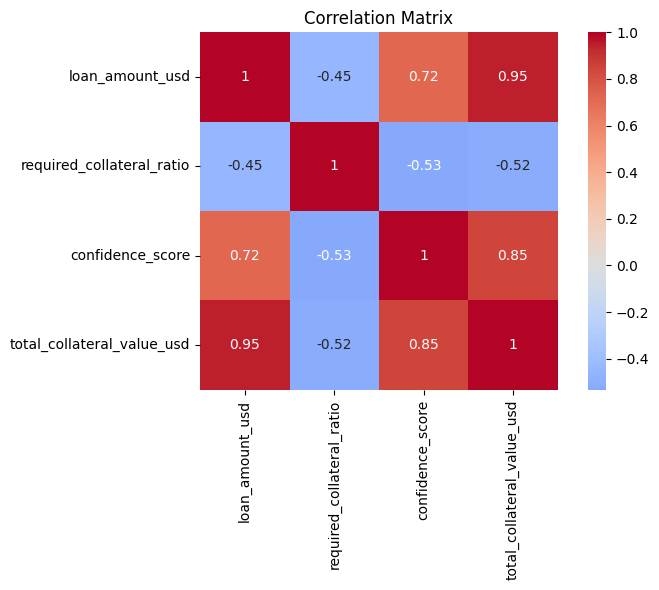

In [12]:
# Correlation analysis
numeric_cols = ['loan_amount_usd', 'required_collateral_ratio', 'confidence_score']
if 'total_collateral_value_usd' in df.columns:
    numeric_cols.append('total_collateral_value_usd')

corr_matrix = df[numeric_cols].corr()
print("📊 Correlation Matrix:")
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
# Summary statistics by risk level
print("📊 Summary by Risk Level:")
summary = df.groupby('risk_level').agg({
    'required_collateral_ratio': ['mean', 'std', 'count'],
    'confidence_score': ['mean', 'std'],
    'loan_amount_usd': ['mean', 'std']
}).round(3)

print(summary)

📊 Summary by Risk Level:
           required_collateral_ratio              confidence_score       \
                                mean    std count             mean  std   
risk_level                                                                
critical                       2.324  0.257    30            0.680  0.0   
high                           2.038  0.114     8            0.680  0.0   
medium                         1.663  0.000     3            0.687  0.0   

           loan_amount_usd            
                      mean       std  
risk_level                            
critical          8666.667  3198.419  
high              5000.000     0.000  
medium           20000.000     0.000  


In [14]:
# Export summary
summary_data = {
    'database_info': {
        'size_kb': round(db_path.stat().st_size / 1024, 1),
        'total_analyses': len(df),
        'tables': len(tables)
    },
    'risk_distribution': dict(risk_counts),
    'collateral_stats': {
        'mean': round(ratios.mean(), 3),
        'median': round(ratios.median(), 3),
        'min': round(ratios.min(), 3),
        'max': round(ratios.max(), 3)
    },
    'loan_patterns': patterns
}

print("📋 Database Summary:")
print(json.dumps(summary_data, indent=2))

# Save to file
with open('db_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print("\n💾 Summary saved to db_summary.json")

# Close connection
conn.close()
print("✅ Analysis complete!")

📋 Database Summary:


TypeError: Object of type int64 is not JSON serializable